In [1]:
#import
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

2025-10-19 13:54:23.309471: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-19 13:54:23.379239: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-19 13:54:24.560713: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Part 1
***Load Data***<br>
The temperature sequence data has been loaded using the provided load_data() function from the pickle file temperatures-2025.pkl, as instructed in the project description.

In [2]:
#Loading data
def load_data(picklefile):
    import pickle
    f = open(picklefile, "rb")
    data = pickle.load(f)
    f.close()
    return data
    
(train_seq, val_seq, test_seq) = load_data("temperatures-2025.pkl")

#Checking shapes
print("Train Shape:", train_seq.shape)
print("Val Shape:", val_seq.shape)
print("Test Shape:", test_seq.shape)

Train Shape: (1490, 84, 2)
Val Shape: (109, 84, 2)
Test Shape: (105, 84, 2)


I0000 00:00:1760882065.147655  179283 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13760 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


To ensure the data was loaded correctly, the shapes of the training, validation, and test sets were printed and inspected.

## (a) Split Sequences

I have created a function called split_seq() to split the full sequence into input and target parts. This function will be useful in Part F, where different combinations of input and target lengths are tested to evaluate how well the models perform across different forecasting horizons.


In [3]:
#Splitting
def split_seq(sequences, input_len, target_len):
    """
    Splits a full temperature sequence into input and target parts.

    Logic:
    This function divides each sequence into two segments. The first input_len timesteps are used as the model input (X). 
    The following target_len timesteps are used as the prediction target (y). This is used to prepare data for training, validation, 
    and testing across all models which will be helpful in part f.

    Parameters:
    sequences: Input dataset to split
    input_len: Number of timesteps to use as model input.
    target_len: Number of timesteps to predict ahead.

    Returns:
    X: Splitted input sequence 
    y: Splitted target sequence

    """

    X = sequences[:, :input_len, :]
    y = sequences[:, input_len:input_len + target_len, :]
    return X, y

#Splitting data
X_train, y_train = split_seq(train_seq, input_len=72, target_len=12)
X_val, y_val = split_seq(val_seq, input_len=72, target_len=12)
X_test, y_test = split_seq(test_seq, input_len=72, target_len=12)

## (b) Display Temprature
To visualise the temperature sequences, I have created a helper function called display_temperatures(). This function will be used to visualise any temprature sequences all over the notebook. The detial about the function is mentioned below in docstring. 


Training Samples:


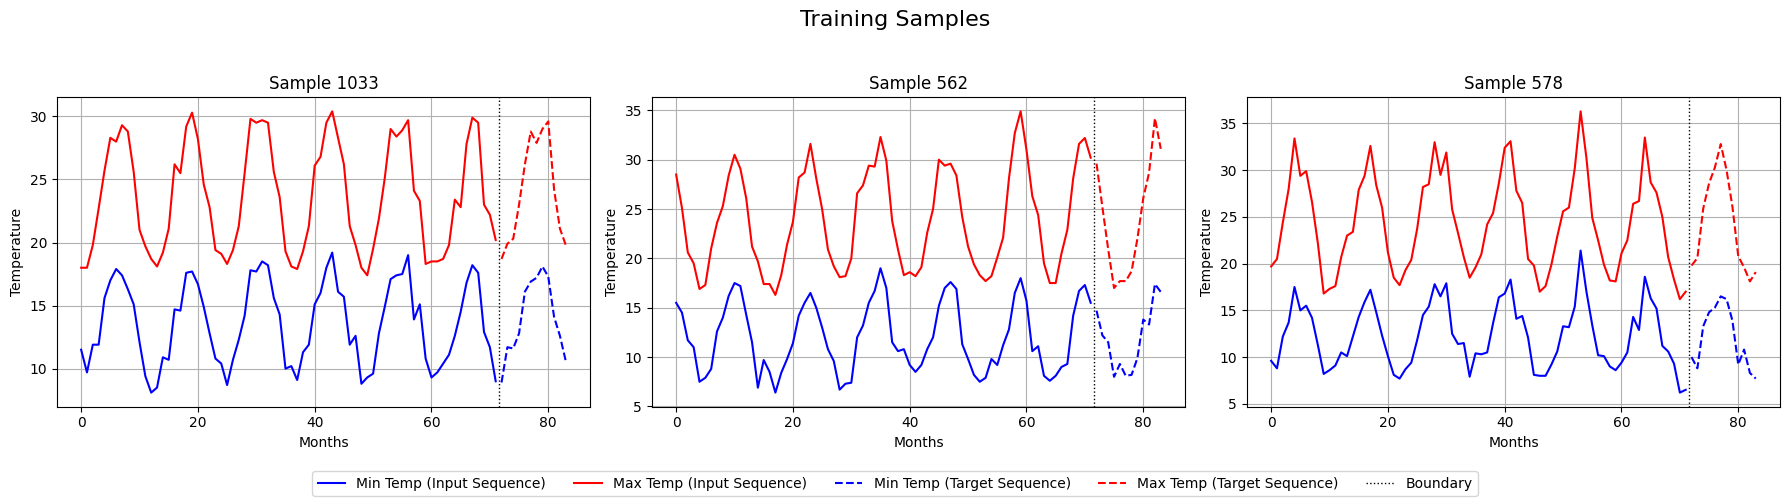

Validation Samples:


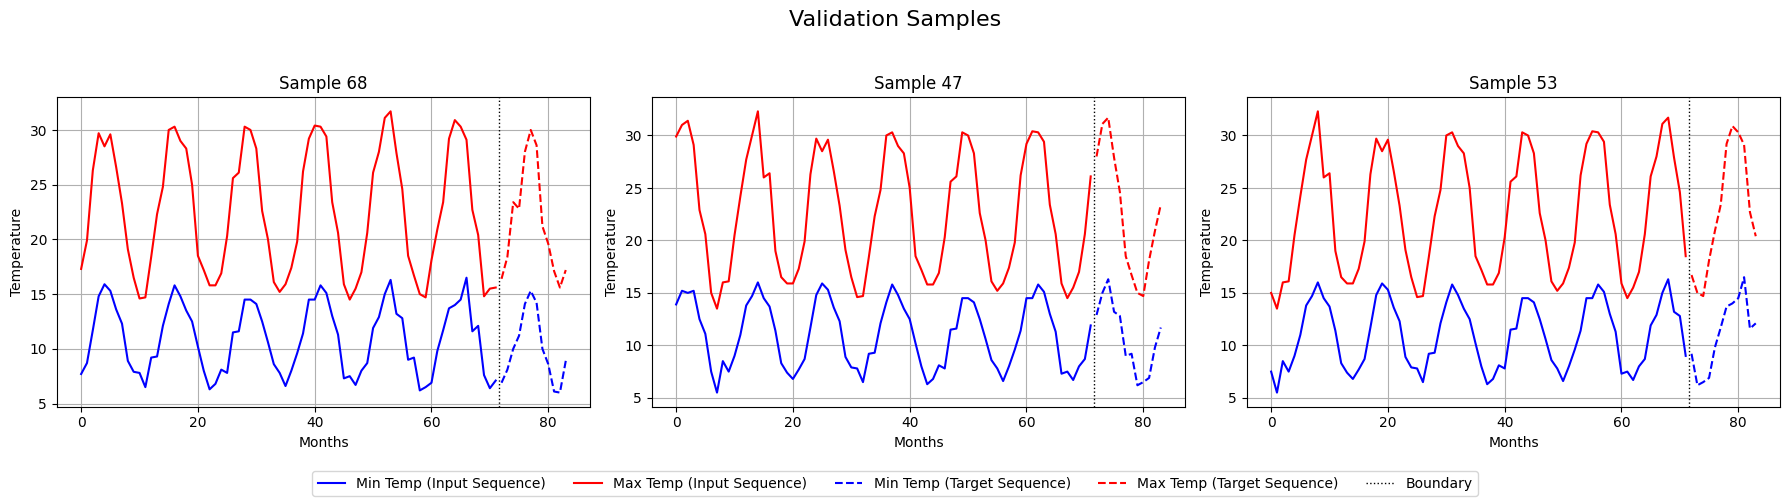

Test Samples:


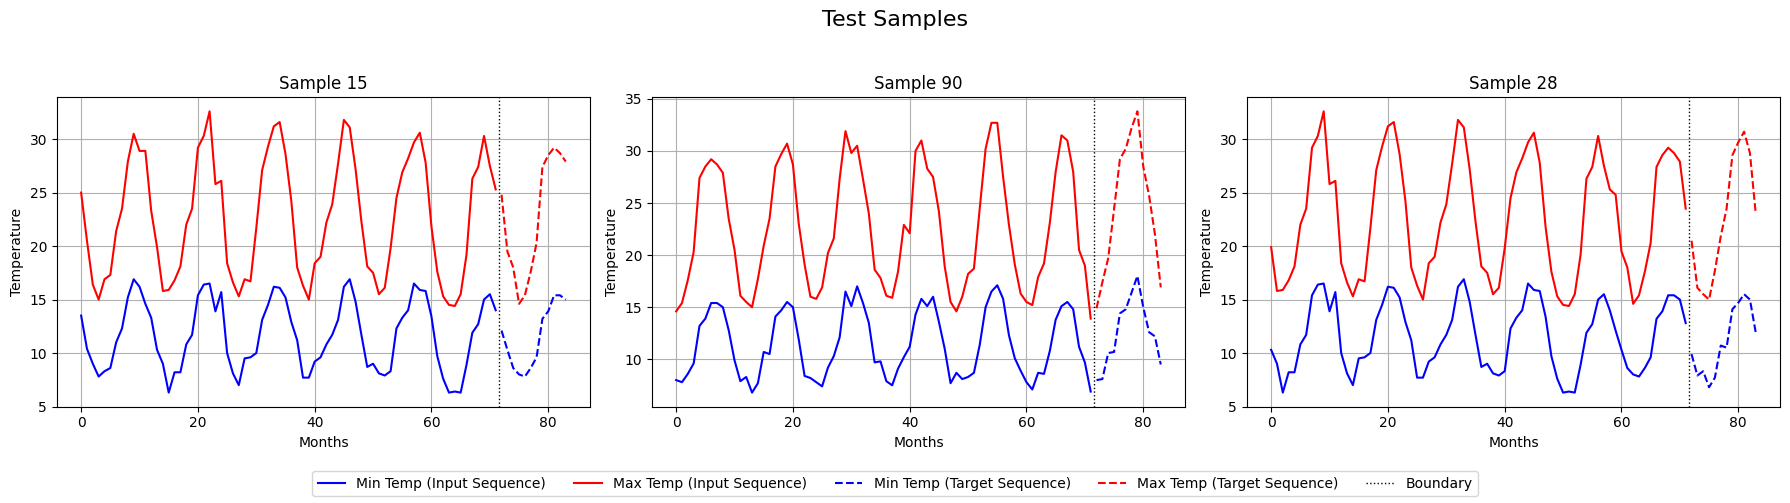

In [4]:
#Display temperature function
def display_temperatures(X=None, y=None, y_pred=None, title=None,n_rows = 1, n_cols=3, num_samples = 3, figsize = (18,5), input_len=72, target_len=12, decoded_sequences = None, n_samples = None, mode = None):
    """
    Displayes temprature sequence using side by side subplots.
    Randomly selects a few samples from the dataset. Shows input sequence, target sequence, and predicted sequence (if provided).
    A vertical boundary line is drawn to separate input and target regions. Special markers are used when target length is 1 (for Model 2 1 month only prediction).

    When mode='synthesized' (for VAE): Plots n_samples decoded sequences from latent space (used for visualizing generated samples).

    Parameters:
    X: Input sequence of shape [batch_size, input_len, 2].
    y: Target sequence of shape [batch_size, target_len, 2].
    y_pred: Predicted sequence of shape [batch_size, target_len, 2] (optional).
    title: Title for the figure.
    n_rows: Number of rows in subplot grid.
    n_cols: Number of columns in subplot grid.
    num_samples: Number of random samples to visualize (for model predictions).
    figsize: Size of the overall figure.
    input_len: Length of input sequence (default is 72 months).
    target_len: Length of target sequence (default is 12 months).
    decoded_sequences: generated sequences (used when mode='synthesized').
    n_samples: Number of VAE sequences to visualize (used when mode='synthesized').
    mode: Plotting mode. If "synthesized", plots decoded VAE sequences. Otherwise, plots actual, predicted samples.

    Returns:
    None. Displays plots.

    """

    #For VAE
    if mode == 'synthesized':
        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=True, sharey=True)
        axes = axes.flatten() if n_cols > 1 else [axes]
        for i in range(num_samples):
            axes[i].plot(decoded_sequences[i], color = 'blue')
            axes[i].set_title(f"{title}{i+1}")
            axes[i].set_xlabel("Month")
            axes[i].set_ylabel("Max Temperature")
            axes[i].grid(True)
        plt.tight_layout()
        plt.show()
    else:
        #For raw samples
        indices = np.random.choice(len(X), num_samples, replace=False)
        fig, axes = plt.subplots(n_rows, n_cols, figsize = figsize)
        for i, idx in enumerate(indices):
            ax = axes[i]
            input_sequence = X[idx]
            target_sequence = y[idx]
            predicted_sequence = y_pred[idx] if y_pred is not None else None
            min_input = input_sequence[:, 0]
            max_input = input_sequence[:, 1]
            min_true = target_sequence[:, 0]
            max_true = target_sequence[:, 1]
            ax.plot(range(input_len), min_input, label="Min Temp (Input Sequence)", color='blue')
            ax.plot(range(input_len), max_input, label="Max Temp (Input Sequence)", color='red')
            ax.plot(range(input_len, input_len + target_len), min_true, label="Min Temp (Target Sequence)", color='blue', linestyle='--', marker = 'o' if target_len == 1 else None)
            ax.plot(range(input_len, input_len + target_len), max_true, label="Max Temp (Target Sequence)", color='red', linestyle='--', marker = 'o' if target_len == 1 else None)
            
            #For predictions
            if predicted_sequence is not None:
                min_pred = predicted_sequence[:, 0]
                max_pred = predicted_sequence[:, 1]
                ax.plot(range(input_len, input_len + target_len), min_pred, label="Min Temp (Predicted)", color='red', linestyle=':', marker = 'o' if target_len == 1 else None)
                ax.plot(range(input_len, input_len + target_len), max_pred, label="Max Temp (Predicted)", color='blue', linestyle=':', marker = 'o' if target_len == 1 else None)
            if i == 0:
                ax.axvline(x=(input_len-0.5), color='black', linestyle=':', linewidth=1, label="Boundary")
            else:
                ax.axvline(x=(input_len-0.5), color='black', linestyle=':', linewidth=1)
                    
            ax.set_title(f"Sample {idx}")
            ax.set_xlabel("Months")
            ax.set_ylabel("Temperature")
            ax.grid(True)
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=7)
        fig.suptitle(title, fontsize=16)
        plt.tight_layout(rect=[0, 0.07, 1, 0.95])
        plt.show()


#Visualize some random samples
print("Training Samples:")
display_temperatures(X_train, y_train, title="Training Samples", figsize=(18,5), num_samples=3, n_rows=1, n_cols=3)
print("Validation Samples:")
display_temperatures(X_val, y_val, title="Validation Samples", figsize=(18,5), num_samples=3, n_rows=1, n_cols=3)
print("Test Samples:")
display_temperatures(X_test, y_test, title="Test Samples", figsize=(18,5), num_samples=3, n_rows=1, n_cols=3)

The above plots display three randomly selected samples from the training, validation, and test sets, respectively. Each plot shows the input temperature sequence and the target sequences for both minimum and maximum temperatures.

One important observation across all three plots is that the temperature values are always positive, with minimum temperatures ranging around (5 - 15) degree C and maximum temperatures around (15–35) degree C.

## Helper Functions:
To make the code modular and reuse the functions again and again across the notebook, I have created helper functions in this section. This makes the workflow clean and easy to manage.
The following functions were created:

- train_model(): Used to train the model with the given training and validation sets.

- plot(): Plots the training curves like to show model performance.

- rolling_forecast() and rolling_predictions(): These functions are designed to match the prediction style mentioned in the project description. They handle the prediction strategy for Model 2 and Model 3.

- evaluate(): Used to make predictions on the test set and calculate the performance metrics.


For data preparation specific to Model 2 and Model 3, I have also created:

- prepare_input_model2(): Prepares the input format for the one-step rolling forecast used in Model 2.

- prepare_decoder_input(): Prepares the decoder input required in the Encoder-Decoder structure used by Model 3.

All of these functions include proper docstrings where I have explained the purpose of the function, its input parameters, logic, and what it returns.



In [5]:
#Helper functions
#Train the model
def train_model(model, X_train, y_train, X_val, y_val, 
                batch_size=32, epochs=100, stop=10, reduceOn=4, reduceBy=0.5, min_lr=1e-6):
    """
    Trains model using early stopping and learning rate scheduling.

    Parameters: 
    model: Compiled model to be trained
    X_train, y_train, X_val, y_val: Input data
    Batch size: Default kept to be 32
    epochs: Maximum number of epochs to train default kept to 100 as per the project specification
    reduceOn: Number of epochs with no improvement after which learning rate will be reduced (patience for ReduceLROnPlateau). Default is 4.
    reduceBy: Factor by which the learning rate is reduced. Default is 0.5(50%)
    min_lr: Lowest LR scheduler could reduce

    Return:
    History that contains training and validation loss metrics per epoch which can be used to observe the model training performance.

    """
        

    #Early stopping setup
    early_stop = tf.keras.callbacks.EarlyStopping( monitor='val_loss', patience=stop, 
                                                                restore_best_weights=True)
    
    #Learning rate scheduler
    plateau = tf.keras.callbacks.ReduceLROnPlateau( monitor='val_loss', factor=reduceBy, 
                                                patience=reduceOn, min_lr=min_lr, verbose=0)
    

    #Fitting the models
    history = model.fit( X_train, y_train, validation_data=(X_val, y_val), 
                        batch_size=batch_size, epochs=epochs, callbacks=[plateau, early_stop], 
                        verbose=0)

    return history


#Need to plot side by side plots instead of two
#Plotting the curves
def plot(history):
    """
    Plots training diagnostics using two side by side subplots which is helpful to understand how the model is learning.
    Parameters:
    History: History object containing training logs.
    Returns:
    None. Displays the plots directly.
    """

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    #Learning Rate vs Validation Loss
    ax1 = axes[0]
    ax1.plot(history.epoch, history.history["learning_rate"], "bo-")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Learning Rate", color='b')
    ax1.tick_params(axis='y', colors='b')
    ax1.grid(True)
    ax1.set_xlim(0, len(history.epoch) - 1)

    ax1b = ax1.twinx()
    ax1b.plot(history.epoch, history.history["val_loss"], "r^-")
    ax1b.set_ylabel('Validation Loss', color='r')
    ax1b.tick_params(axis='y', colors='r')
    ax1.set_title("Reduce LR on Plateau", fontsize=14)

    #MAE and Loss
    ax2 = axes[1]
    ax2.plot(history.epoch, history.history['mae'], "b-", label='Train MAE')
    ax2.plot(history.epoch, history.history['val_mae'], "b--", label='Val MAE')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MAE', color='b')
    ax2.tick_params(axis='y', labelcolor='b')
    ax2.set_xlim(0, len(history.epoch) - 1)
    ax2.grid(True)

    ax2b = ax2.twinx()
    ax2b.plot(history.epoch, history.history['loss'], "r--", label='Train Loss')
    ax2b.plot(history.epoch, history.history['val_loss'], "r-", label='Val Loss')
    ax2b.set_ylabel('Loss', color='r')
    ax2b.tick_params(axis='y', labelcolor='r')

    lines = ax2.get_lines() + ax2b.get_lines()
    labels = [line.get_label() for line in lines]
    ax2.legend(lines, labels, loc='center right')
    ax2.set_title("MAE and Loss over Epochs")

    plt.tight_layout()
    plt.show()


#Rolling forecast - Model2 uses this mode
def rolling_forecast(model, X_test, steps=12):

    """
    Performs a rolling multi step forcast using a trained model

    Logic:
    After each prediction, the input window is shifted by one step and newely predicted value is appended to form the next input. This method is used to make 
    prediction in model 2 where model predicts one month at a time and continues rolling forward.

    Parameters:
    model: Trained model used for prediction
    X_test: Initial input sequence
    Steps: Number of future timesteps to predict recursively. Default is 12

    Returns: Predictted values for the specified number of steps

    """
    predictions = []
    current = X_test
    for _ in range(steps):
        next_month = model.predict(current[np.newaxis, ...], verbose=0)[0, 0]
        predictions.append(next_month)

        #Slide window forward
        current = np.concatenate([current[1:], next_month.reshape(1, 2)], axis=0)
    return np.array(predictions)


#Rollout Predictions - Model3 uses this mode
def rollout_predictions(model, X_test, target_length):
    """
    Generates multi step predictions by recursively feeding the models own outputs back into its input. This function will be used to make predictions for model3
    Only the first timestep uses real data. All remaining steps use the models own previous predictions(no ground truth is used).

    Logic: 
    The function starts by taking the last timestep from X_test as initial input for prediction. A placeholder is created to hold predicted values for the future timesteps.
    At each step 't', the model predicts the entire future sequence, but only the prediction for the current timestep t will be extracted. This prediction is then inserted into the 
    input at position t+1 and used in the next step. This process repeats until all target_length steps are predicted.

    Parameters:

    model: Trained model that expects [X_test, decoder_input] as input. (I will explain about the input preperation for model 3 in prepare_decoder_input() function)
    X_test: input of shape [batch_size, input_len, features], the initial context window.
    target_length: Number of future timesteps to predict.

    Returns:
    y_pred: Predicted sequence of shape [batch_size, target_length, features].

    """

    #Decoder input
    decoder_input = np.zeros((X_test.shape[0], target_length, 2), dtype=np.float32) #matrix of batch size initially with zeroes acts as a placeholder

    #First input should be the last observed timestep from encoder
    decoder_input[:, 0:1, :] = X_test[:, -1:, :]
    predictions = []

    for t in range(target_length):
        #Predict full 12 month sequence
        yhat = model.predict([X_test, decoder_input], verbose=0)

        #Take prediction for current timestep t
        current = yhat[:, t:t+1, :]
        predictions.append(current)

        #Feed it into decoder input for next timestep
        if t + 1 < target_length:
            decoder_input[:, t+1:t+2, :] = current

    #Stack all predicted timesteps
    y_pred = np.concatenate(predictions, axis=1)
    return y_pred

#Evaluate the model
def evaluate(model, X_test, y_test, mode = None, steps=None, target_length=None):
    """
    Evaluates the model on the test set using different prediction modes.

    Logic:
    If mode is None, the model is directly evaluated using model.evaluate() and model.predict(). Normal setup used for model1.
    If mode is "rolling", it performs recursive one step ahead forecasting using the rolling_forecast() function.
    If mode is "rollout", it performs step by step auto regressive prediction using rollout_predictions().

    MAE is manually calculated using mean absolute error for rolling and rollout mode but for normal mode testMAE will be unpacked from the model.predict()

    Parameters:
    model: Trained model to be evaluated.
    X_test: Test input data.
    y_test: Ground truth target data.
    mode: Evaluation mode one of [None, "rolling", "rollout"].
    steps: Number of future steps to predict (used only if mode="rolling").
    target_length: Number of steps to predict (used only if mode="rollout"). 
    (Steps and target_length are doing same but I had to change functions multiple times to make easier to debug i gave seperate name for seperate mode)

    Returns:
    y_pred: Predicted values generated by the model.
    test_mae: Mean Absolute Error between predicted and ground truth values.

    """

    if mode is None:
        loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
        y_pred = model.predict(X_test, verbose=0)

    elif mode == "rolling":
        y_preds = []
        for i in range(len(X_test)):
            predictions = rolling_forecast(model, X_test[i], steps = steps)
            y_preds.append(predictions)
        y_pred = np.array(y_preds)

        test_mae = np.mean(np.abs(y_test - y_pred))

    elif mode == "rollout":
        y_pred = rollout_predictions(model, X_test, target_length=target_length)
        test_mae = np.mean(np.abs(y_test - y_pred))
        
    return y_pred, test_mae


#Only the first month of the 12 for model2 data prep
def prepare_input_model2(seq):
    """
    Extracts only the first timestep from the target sequence for Model 2 training.

    Parameters:
    seq: target sequence of shape [batch_size, target_length, features].

    Returns: First timestep of the sequence with shape [batch_size, 1, features], which is used as the target when training Model 2.

    """
    return seq[:, :1, :]

#Prepare data for decoder
def prepare_decoder_input(X, y):
    """
    Prepares decoder input sequences for Model 3 during training (teacher forcing setup).
    During training, the decoder should not rely on its own predictions, because they may be 
    inaccurate early in training. Instead, it uses the  actual ground truth values as inputs for each timestep.


    Logic: 
    The first timestep input to the decoder comes from the last timestep of X The remaining timesteps come from the ground truth sequence y, 
    excluding the final timestep and concat to form full decoder input.

    Parameters:
    X: Input sequence of shape [batch_size, input_length, features].
    y: Ground truth target of shape [batch_size, target_length, features].


    Returns:
    Tensor of shape [batch_size, target_length, features], representing the decoder input sequence used during training.
    """
    return tf.concat([X[:, -1:, :], y[:, :-1, :]], axis=1)


## (c) Implementation of Model1:
The task was to implement a two layered GRU network that learns 72 months of temperature patterns and predicts the next 12 months of mean minimum and maximum temperatures.

### Architecture
I have implemented the architecture as described in the project specification. The input layer recives the sequences shaped as (None, 2).
- The architecture is built using the Sequential API with the following layers:  
  - First GRU layer: 8 units, return_sequences=True to pass output to the next GRU layer.  
  - Second GRU layer: 16 units, return_sequences=False to return only the final hidden state.  
  - Dense layer: target_length * 2 units to output the predicted maximum and minimum temperatures for 12 month [which is 24 month]. 
  - Reshape layer: Ensures the output shape is (target_length, 2).


***Training Setup***<br>
The model was compiled using the Nadam optimizer, MAE as both the loss function and evaluation metric. It was then trained using train_model() function to predict 12 month ahead temprature. The target (y_train) for training contained the full 12 month sequences.

***Why RELU?***<br>
I have chosen RELU to be the candidate activation function because on inspecting the dataset i found that the temprature were always positive which means, the pre activation is less likely to be negative due to input only. However, since the pre activation also depends on the recurrent contribution from the previous hidden state and on the learned weights and biases which can be both positive and negative so, negative values may still occur. When this happens, the ReLU clips these values to zero, deactivating those neurons which might result in dead neurons.

In practice, this behaviour was not problematic, while running the experimental training it showed stable convergence and effective learning. This indicates that dead neurons might be minimal and that information continued to propagate effectively through time. ReLU is also beneficial from an optimization perspective because its derivative is 1 for all positive inputs, which ensures gradients flow without vanishing in the positive region. As a result, ReLU often operates in its linear region, making it both efficient and a suitable choice for this dataset.

I compared the model using ReLU with another version using tanh (after input scaling). The MAE values were found to be similar. So, i decided to pick relu over other activation functions.

Model: "Model1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, None, 8)        │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 16)             │         1,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 12, 2)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,944 (7.59 KB)

 Trainable params: 1,944 (7.59 KB)

 Non-trainable params: 0 (0.00 B)

2025-10-19 13:54:30.609007: I external/local_xla/xla/service/service.cc:163] XLA service 0xf124520 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-19 13:54:30.609026: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2025-10-19 13:54:30.702596: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-19 13:54:31.064641: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
I0000 00:00:1760882072.756539  179317 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


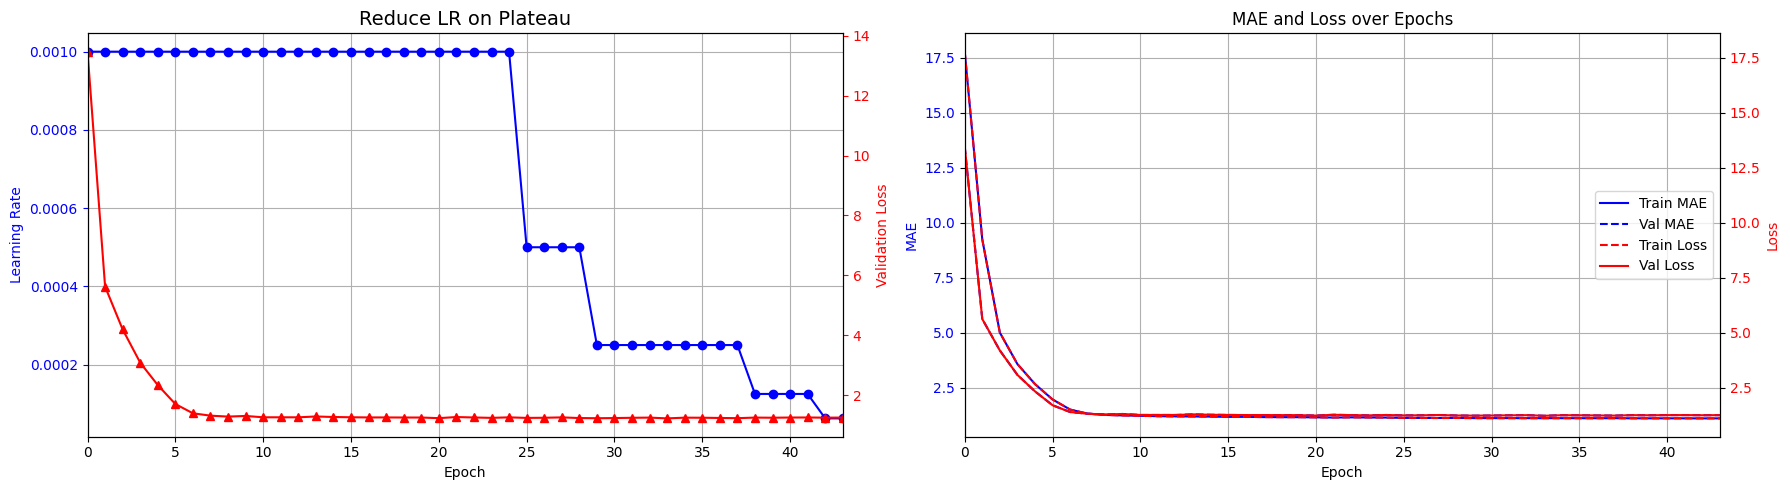

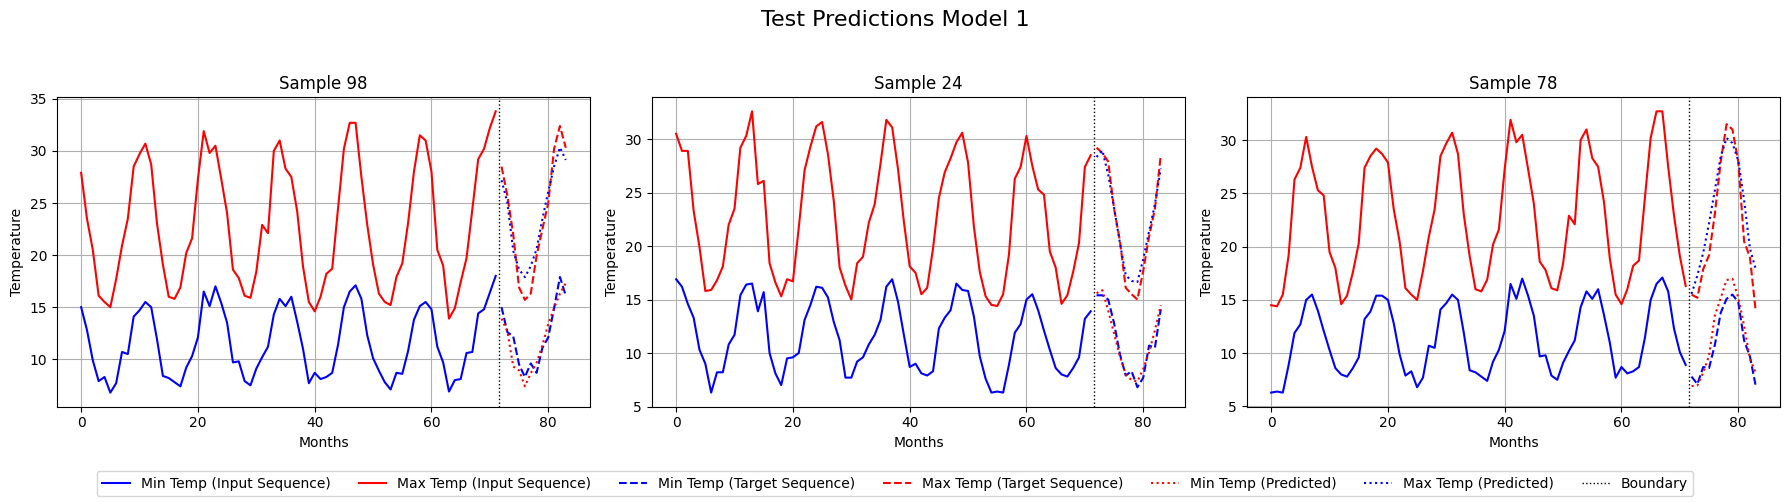

Test MAE for model1 is 1.2704 degree C


In [6]:
#model1
def create_model1(target_length):
    model1 = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(None,2)),
        tf.keras.layers.GRU(8, activation='relu', return_sequences=True),
        tf.keras.layers.GRU(16, activation='relu', return_sequences=False),
        tf.keras.layers.Dense(target_length * 2),
        tf.keras.layers.Reshape((target_length, 2))
    ], name='Model1')
    return model1

model1 = create_model1(12) #Target is 12 month
#Summary
model1.summary()

#Compile and train
model1.compile(optimizer = tf.keras.optimizers.Nadam(), loss = 'mae', metrics = ['mae'])
history = train_model(model1, X_train, y_train, X_val, y_val, batch_size=32, epochs=100)

#Plot
plot(history)

#Evaluate and plot
y_pred1, mae_partc = evaluate(model1, X_test, y_test)
display_temperatures(X_test, y_test, y_pred1, title="Test Predictions Model 1",figsize=(18,5), num_samples=3, n_rows=1, n_cols=3)

#Note MAE
print(f"Test MAE for model1 is {mae_partc:.4f} degree C")

### Discussions
***Parameters Summary***<br>
The model contains a total of 1,944 trainable parameters and no non-trainable parameters.  

***LR Scheduling***<br>
The learning rate was initially set to 0.001. As seen in the plot, the learning rate remained constant for the first 20 epochs and then decreased in multiple steps around epochs 22, 35, and 50. This adaptive adjustment allowed the model to tune its learning once the validation loss stopped improving. The validation loss dropped sharply during the early epochs, showing rapid learning, and then gradually flattened as the learning rate reduced. This behaviour indicates that the scheduler effectively helped the model converge smoothly and avoid over shooting the minima.

***Learning Curves***<br>
The learning curves for both MAE and loss shows smooth convergence. In the initial epochs, the model significantly reduces both training and validation errors, indicating effective early learning. After around epoch 10, the curves flatten and remain stable. The training and validation metrics stay tightly aligned throughout, with no signs of overfitting this shows the model generalizes well. 

***Test Predictions***<br>
The test predictions plotted for 3 random test samples show significant alignment between predicted and ground truth sequences across both minimum and maximum temperatures. The predicted values closely follow seasonal trends and magnitudes. Minor deviations occur in some months but remain within acceptable error bounds. The model successfully captures the pattern confirming that the two layer GRU has effectively learned. This behaviour was expected because the model is evaluated in the same setup as it was trained on, enabling it to maintain consistency and generalize effectively across unseen test samples.

***MAE***<br>
The final Test MAE for Model1 is 1.3332 degree. That means on average, the predicted temperature deviates from the actual temperature by about 1.3332 degree over 12 months.

## (d) Implementation of Model2:
The task was to design and implement a two layered GRU model that learns temperature patterns from the past 72 months and predicts the next 1 month’s minimum and maximum temperatures.


### Architecture
I have implemented the architecture as described in the project specification. The input layer recives the sequences shaped as (None, 2).
- The model is built using the Sequential API with the following layers:  
  - First GRU layer: 8 units, return_sequences=True to pass output to the next GRU layer.  
  - Second GRU layer: 16 units, return_sequences=False to return only the final hidden state.  
  - Dense layer: 2 units to output the predicted maximum and minimum temperatures for 1 month.  
  - Reshape layer: Ensures the output shape is (1, 2) to maintain consistency with the rolling forecast format.
  
***Training Setup***<br>
The model was compiled using the Nadam optimizer, MAE as both the loss function and evaluation metric. It was then trained using train_model() function. To train the model for 1 month ahead prediction, the target sequences (y_train and y_val) were trimmed to include only the first month of each 12 month target using the prepare_input_model2() function.


Model: "Model2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, None, 8)        │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 16)             │         1,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            34 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 1, 2)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,570 (6.13 KB)

 Trainable params: 1,570 (6.13 KB)

 Non-trainable params: 0 (0.00 B)

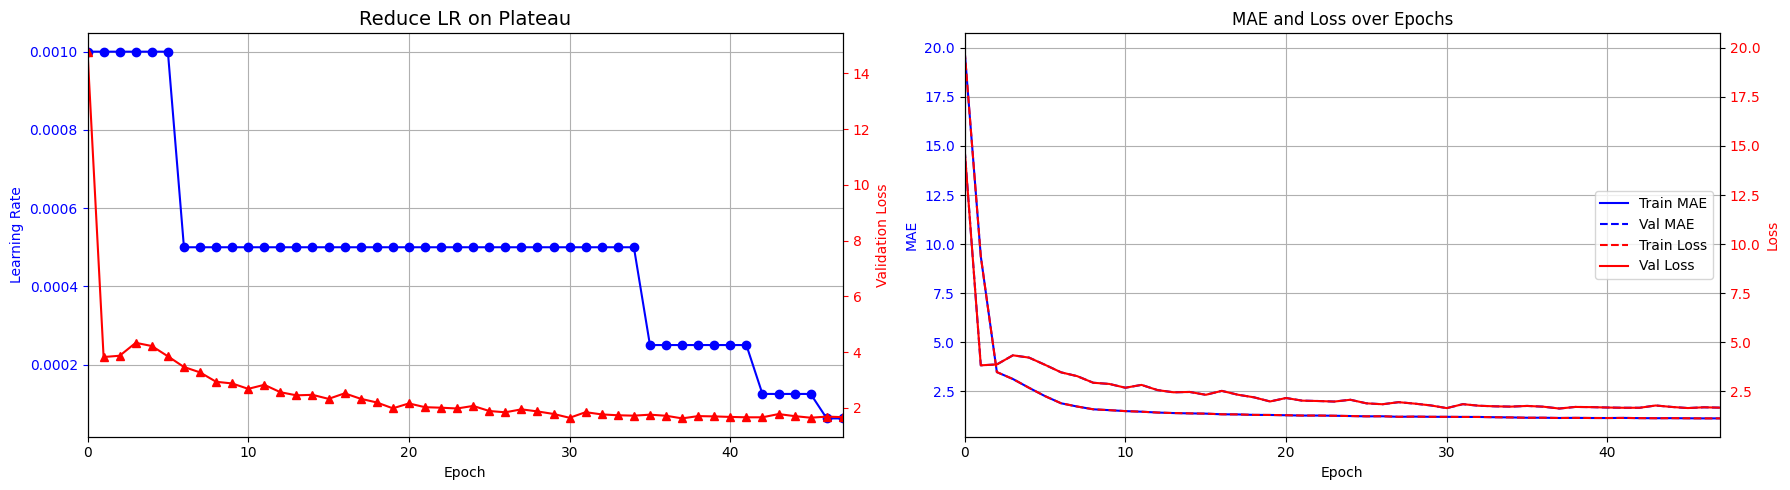

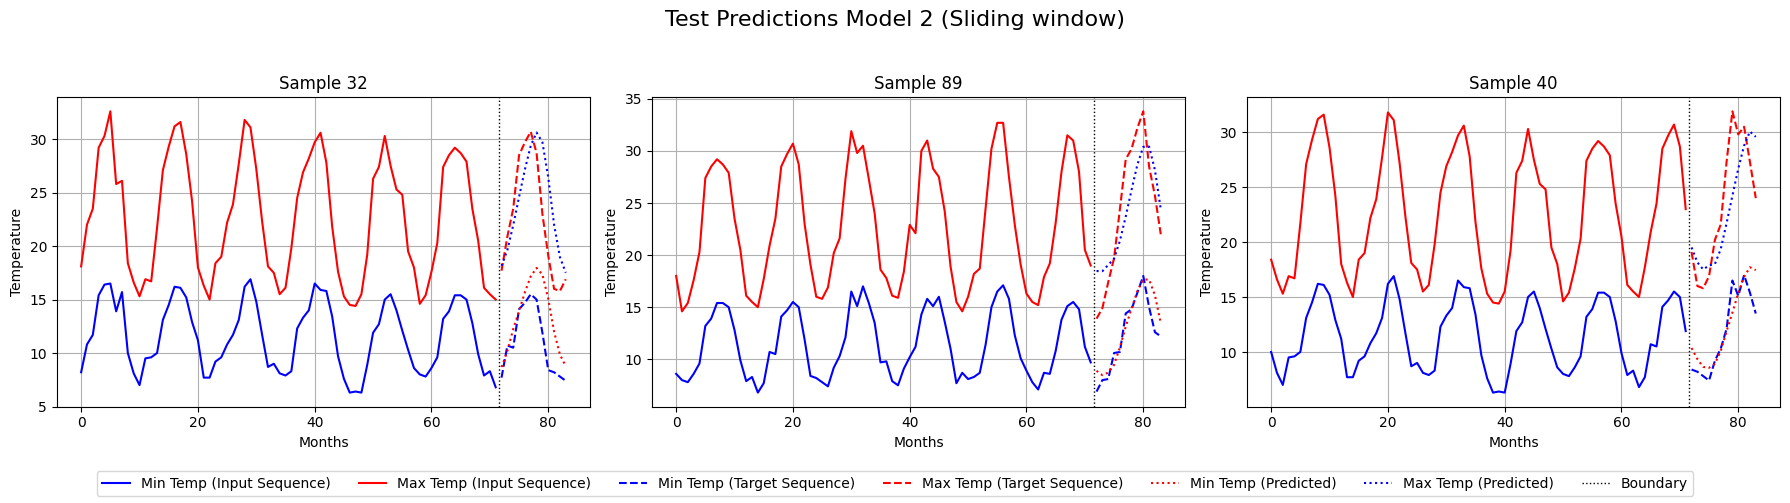

Test MAE for model2 while doing the rolling forecast is 2.1037 degree C


In [7]:
#Implement model2
#Only the first month of the 12 - So modify y to only have the first month
y_train_1mnth = prepare_input_model2(y_train)
y_val_1mnth = prepare_input_model2(y_val)

def create_model2(target_length):
    model2 = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(None,2)),
        tf.keras.layers.GRU(8, activation='relu', return_sequences=True),
        tf.keras.layers.GRU(16, activation='relu', return_sequences=False),
        tf.keras.layers.Dense(2),
        tf.keras.layers.Reshape((target_length, 2))
    ], name='Model2')
    return model2
    

model2 = create_model2(1) #Target is one month 

#Summary
model2.summary()

model2.compile(optimizer=tf.keras.optimizers.Nadam(), loss='mae', metrics=['mae'])
history2 = train_model(model2, X_train, y_train_1mnth, X_val, y_val_1mnth)

#Plot
plot(history2)

#Evaluate and plot
y_pred2, mae_partd = evaluate(model2, X_test, y_test, steps = 12, mode = "rolling")
display_temperatures(X_test, y_test, y_pred2, title="Test Predictions Model 2 (Sliding window)",figsize=(18,5), num_samples=3, n_rows=1, n_cols=3)

#Note MAE
print(f"Test MAE for model2 while doing the rolling forecast is {mae_partd:.4f} degree C")

### Discussions:

***Parameters Summary***<br>
The model contains a total of 1,570 trainable parameters and no non trainable parameters.  

***LR Scheduling***<br>
The learning rate was initially set to 0.001. In the plot, it can be seen that the learning rate remained constant for the first 25 epochs, after which it dropped three times. This adaptive adjustment allowed the model to tune its performance as training progressed. The validation loss dropped sharply in the first few epochs and then gradually flattened, indicating that the model quickly learned then became stable.

***Learning Curve***<br>
The learning curves for both MAE and loss show a rapid and stable convergence. In the first few epochs, the model quickly reduces both training and validation errors, indicating effective early learning. After around epoch 7, the curves begin to flatten and remain consistent throughout the rest of training. Both the training and validation curves closely follow each other, with no significant gap. This behaviour was expected because model is learning from 72 months to predict just one. <br>

***Test Predictions(Sliding Window)***<br>
The plot above shows the 12 month rolling predictions made by Model 2 on three randomly selected test samples. Each subplot spans an 84 month window, where the first 72 months represent the input sequence and the last 12 months represent the predicted and target sequences. Despite being trained for only 1 month ahead prediction, Model 2 performs well when used in a rolling forecast loop. The predicted sequences generally align closely with the ground truth, capturing trends in both max and min temperatures. Some small deviations appear toward the end of the predicted horizon, which is expected due to error accumulation in the autoregressive setup. The overall continuity and accuracy across the forecast window suggest that Model 2 is generalizing effectively even in a multi step setting.

***MAE***<br>
The reported MAE was 1.1942 while doing the rolling forecast is 1.1942 degree C. I was expecting this value to be higher than that of Model 1, since Model 2 is trained to predict only one month at a time and relies on its own previous predictions for forecasting subsequent months. This autoregressive setup increases the risk of error accumulation, which can degrade performance over multiple steps. To investigate this further, I plan to evaluate the model's performance on just the first month prediction and compute the MAE.

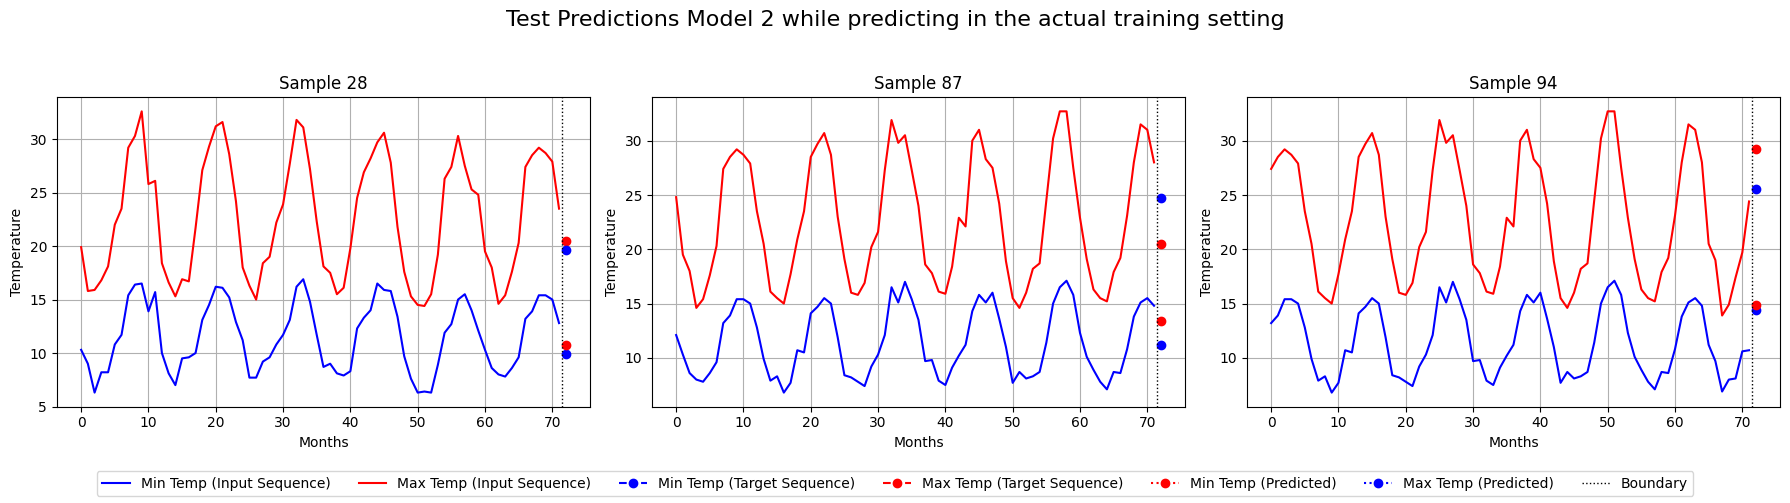

Test MAE for model2 while predicting single month is 1.4896 degree C


In [8]:
#Predict how good the model was on the actual training setting:
y_pred_single, test_mae2_single = evaluate(model2, X_test, y_test[:, :1, :])
display_temperatures(X_test, y_test[:,:1,:], y_pred_single, title="Test Predictions Model 2 while predicting in the actual training setting",figsize=(18,5), num_samples=3, n_rows=1, n_cols=3, target_len=1)

#Note MAE
print(f"Test MAE for model2 while predicting single month is {test_mae2_single:.4f} degree C")

***Comment on 1 month Prediction***<br>
As shown in the plot above, the model predicts the next month's maximum and minimum temperatures maintaining strong alignment with the ground truth. The Test MAE for single month prediction was 1.0568°C, which is noticeably good. This solid performance on the first prediction likely contributed to the relatively low error observed during the 12 step rolling forecast. If the initial prediction had a high error, that mistake would have propagated and amplified across subsequent steps.

This confirms that Model 2 performs very well for single step forecasting, and the slight increase in error during the 12 step forecast is due to error propagation each subsequent prediction depends on previous predicted values rather than true observations.

## (e) Implementation of Model3
The task was to design and implement a two layered GRU Encoder Decoder architecture to perform 12 month temperature prediction.

### Architecture:
I have implemented the architecture as described in the project specification. The Encoder receives input sequences shaped as (None, 2), where the two features represent maximum and minimum temperatures. It processes this input through two stacked GRU layers:

Encoder:<br>
- The first GRU layer has 8 units and returns both the full output sequence and its final hidden state with shape (batch_size, 8).  
- The second GRU layer has 16 units and returns only the final hidden state with shape (batch_size, 16).

These two hidden states encoder_hiddenState1 and encoder_hiddenState2 are unpacked and passed directly to the corresponding GRU layers in the Decoder as their initial hidden states.

Decoder:<br>
- The first Decoder GRU layer has 8 units, similar to the first Encoder layer, because out of the two required inputs the input sequence and the initial hidden state the hidden state is passed directly from the first Encoder GRU layer, which would be of shape (batch_size, 8). To be compatible, the Decoder GRU must have the same number of units (8) so it can correctly accept the encoder's hidden state as its initial state without any shape mismatch.
- The second Decoder GRU layer uses encoder_hiddenState2, which is passed from the second GRU layer of the encoder, so it needs to accept the same shape as that hidden state. That’s why I am using 16 units here, matching the second Encoder layer. Since the hidden state coming from the encoder has a shape of (batch_size, 16), the Decoder GRU must also have 16 units to avoid shape mismatch.
- At the end of the Decoder, a Dense layer with 2 neurons is applied to predict two values which is  maximum and minimum temperatures.


***Training setup***<br>
The model is then compiled using the Nadam optimizer, with MAE as evaluation metric. It is trained using the custom train_model() function. As per the project specification, the data was prepared to support teacher forcing meaning the Decoder does not rely on its own predictions during training. Instead, it receives the ground truth target values from previous time steps. This is achieved by passing the decoder inputs X_train_decoder and  X_val_decoder alongside the encoder inputs during training. This allows the model to adjust its internal weights based on the true expected outputs, rather than being influenced by its own potentially inaccurate earlier predictions. As a result, error does not accumulate or drift over time during training leading to more stable and effective learning.

Model: "Model3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, None, 2)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, None, 2)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_4 (GRU)         │ [(None, None, 8), │        288 │ input_layer_2[0]… │
│                     │ (None, 8)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_6 (GRU)         │ [(None, None, 8), │        288 │ input_layer_3[0]… │
│                     │ (None, 8)]        │            │ gru_4[0][1]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_5 (GRU)         │ [(None, 16),      │      1,248 │ gru_4[0][0]       │
│                     │ (None, 16)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_7 (GRU)         │ [(None, None,     │      1,248 │ gru_6[0][0],      │
│                     │ 16), (None, 16)]  │            │ gru_5[0][1]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, None, 2)   │         34 │ gru_7[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,106 (12.13 KB)

 Trainable params: 3,106 (12.13 KB)

 Non-trainable params: 0 (0.00 B)

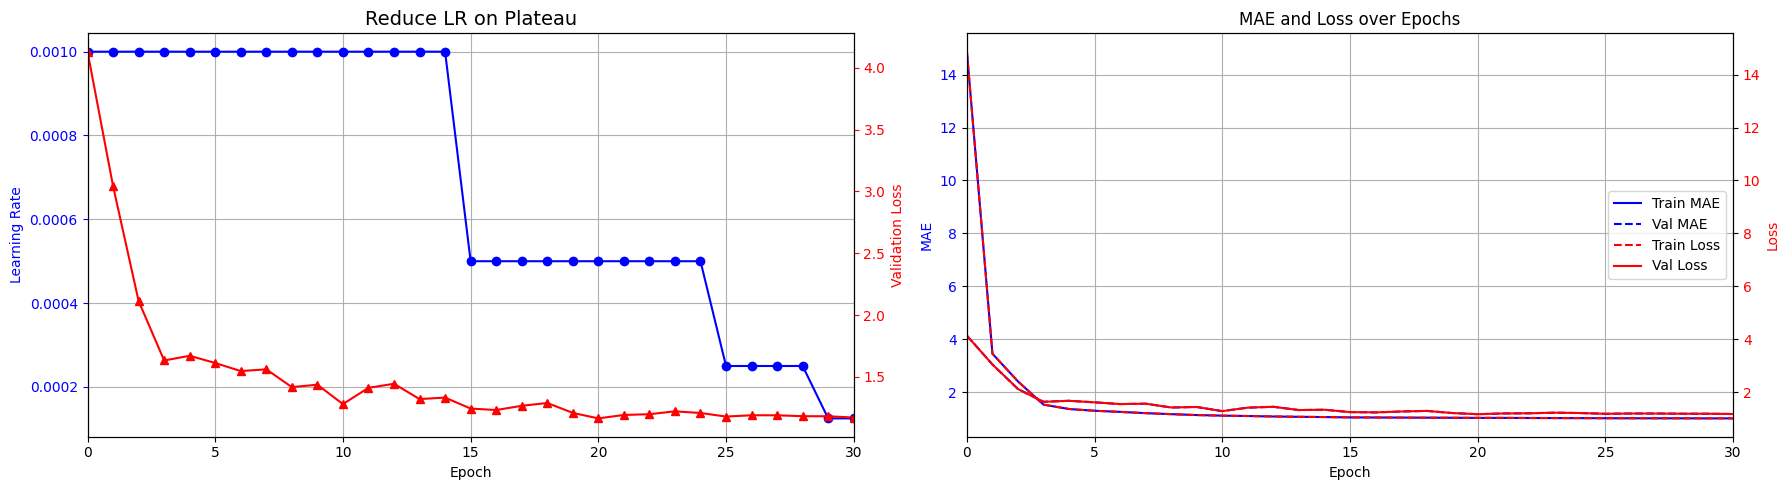

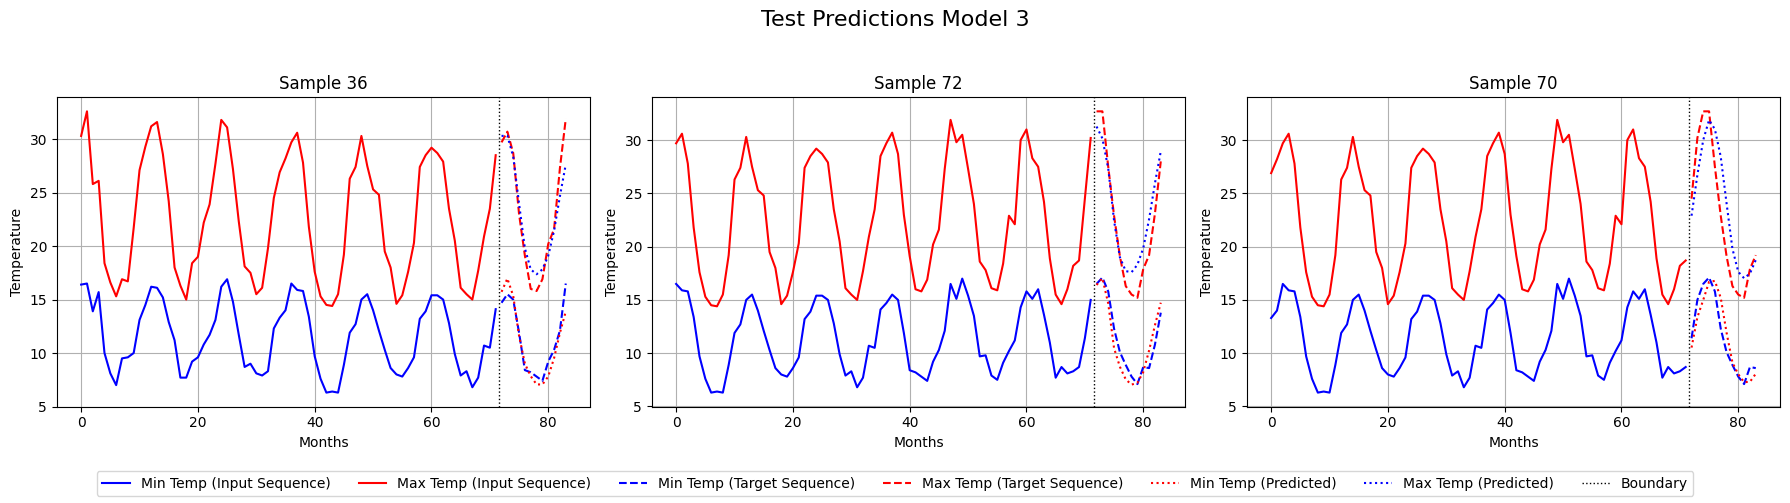

Test MAE for model3 is 1.4566 degree C


In [9]:
#Prepare data for decoder first - to allow teacher forcing
X_train_decoder = prepare_decoder_input(X_train, y_train)
X_val_decoder = prepare_decoder_input(X_val, y_val)

def create_model3():
    #Encoder
    encoder_inputs = tf.keras.Input(shape=(None,2))
    encoder_output1, encoder_hiddenState1 = tf.keras.layers.GRU(8, activation = 'relu', 
                                            return_sequences=True, return_state=True)(encoder_inputs)
    encoder_output2, encoder_hiddenState2 = tf.keras.layers.GRU(16, activation = 'relu', 
                                            return_sequences=False, return_state=True)(encoder_output1)

    #Decoder
    decoder_inputs = tf.keras.Input(shape=(None,2))
    decoder_output1, decoder_hiddenState1 = tf.keras.layers.GRU(8, activation='relu', 
                                            return_sequences=True, return_state=True)(decoder_inputs, initial_state=encoder_hiddenState1)
    decoder_output2, decoder_hiddenState2 = tf.keras.layers.GRU(16, activation='relu', 
                                            return_sequences=True, return_state=True)(decoder_output1, initial_state=encoder_hiddenState2)

    #Output layer
    outputs = tf.keras.layers.Dense(2)(decoder_output2) 
    model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs], outputs=outputs, name="Model3")
    return model

model3 = create_model3()
#Summary
model3.summary()

#Compile and train
model3.compile(optimizer = tf.keras.optimizers.Nadam(), loss = 'mae', metrics = ['mae'])

#I have to pass the actual teacher forcing way:
history3 = train_model(model3, [X_train, X_train_decoder], y_train, [X_val, X_val_decoder], y_val, batch_size=32, epochs=100)

#Plot
plot(history3)

#Evaluate and plot
y_pred3, mae_parte = evaluate(model3, X_test, y_test, target_length=12, mode = "rollout") #Evaluation is being done in rollout mode which i have explained above in the helper functions section
display_temperatures(X_test, y_test, y_pred3, title="Test Predictions Model 3")

#Note MAE
print(f"Test MAE for model3 is {mae_parte:.4f} degree C")


### Discussions 

***Parameters Summary***<br>
The model contains a total of 3,106 trainable parameters and 0 non trainable parameters. The encoder has 1,536 parameters (288 + 1,248 from two GRU layers), while the decoder has 1,570 parameters (288 + 1,248 from GRUs and an additional 34 from the final Dense layer used to generate the output).

***LR scheduler***<br>
The learning rate was initialized at 0.001 and managed using a ReduceLROnPlateau scheduler, which reduces the rate when the validation loss stops improving. As shown in the left plot, there were three noticeable drops in the learning rate.

***Learning Curves***<br>
The training and validation curves for both MAE and loss show a clear and smooth convergence pattern. In the first few epochs, there's a sharp drop, indicating that the model quickly learns the underlying temperature patterns. After around epoch 10, the curves flatten and stabilize with minimal fluctuations. The training and validation metrics stay closely aligned throughout, suggesting that the model generalizes well and is not overfitting.

***Predictions***<br>
As per the project specification the prediction for the test samples was done in rollout mode where rollout performs autoregressive inference where only the first time step uses real data, and all subsequent predictions are based on the model's own outputs. The detial implementation logic for rollout mode have been mentioned in the function. 

The test prediction plot shows the model predicted sequences closely follow the ground truth targets  across all three samples. While minor deviations are observed, they remain within an acceptable range, which suggests that the model generalizes well to unseen data.

***MAE***<br>
The final MAE on test was also low around 1.3402 degree C.


## (f) Comparing the three models for different prediction horizons
The task was to evaluate the performance of three temperature prediction models across different prediction horizons. For that, I created the comparision() function which reuses the earlier helper functions to split the data, train the models, and record the MAEs for each setting and I also created a comparision_plot() function to show how the MAEs change as the prediction horizon increases for all three models. The results are discussed below:

In [10]:
#Function for the Comparision
def comparision(settings, train_seq, val_seq, test_seq):
    """
    
    Runs all three models across multiple prediction horizons.
    For each (input_len, target_len) pair in settings, the function:
    Prepeares the data
    Trains the model
    Records the MAE for each model

    Parameters:
    settings(list of tuples): Each tuple contains (input_length, target_length)
    train_seq(tf.tensor): Full training sequence tensor of shape [samples, timesteps, features]
    val_seq(tf.tensor): Full validation sequence tensor of shape [samples, timesteps, features]
    test_seq(tf.tensor): Full test sequence tensor of shape [samples, timesteps, features]

    Returns:
    model1_MAEs (list of float): MAEs for Model 1 across all settings
    model2_MAEs (list of float): MAEs for Model 2 across all settings
    model3_MAEs (list of float): MAEs for Model 3 across all settings

    """


    #List to store MAE for models
    model1_MAEs, model2_MAEs, model3_MAEs = [], [], []
    
    for input_len, target_len in settings:
        print(f"\nRunning for Input={input_len}, Target={target_len}")
        
        #Prepearing the Sequences
        X_train, y_train = split_seq(train_seq, input_len, target_len)
        X_val, y_val = split_seq(val_seq, input_len, target_len)
        X_test, y_test = split_seq(test_seq, input_len, target_len)
        
        #Model 1
        model1 = create_model1(target_len)
        model1.compile(optimizer = tf.keras.optimizers.Nadam(), loss = 'mae', metrics = ['mae'])
        history = train_model(model1, X_train, y_train, X_val, y_val, batch_size=32, epochs=100)
        _, mae1 = evaluate(model1, X_test, y_test)
        model1_MAEs.append(mae1)
        
        #Model 2
        y_train_1mnth = prepare_input_model2(y_train)
        y_val_1mnth = prepare_input_model2(y_val)
        model2 = create_model2(1)
        model2.compile(optimizer=tf.keras.optimizers.Nadam(), loss='mae', metrics=['mae'])
        history2 = train_model(model2, X_train, y_train_1mnth, X_val, y_val_1mnth)
        _, mae2 = evaluate(model2, X_test, y_test, mode = "rolling", steps = target_len)
        model2_MAEs.append(mae2)
        
        #Model 3
        X_train_decoder = prepare_decoder_input(X_train, y_train)
        X_val_decoder = prepare_decoder_input(X_val, y_val)
        model3 = create_model3()
        model3.compile(optimizer = tf.keras.optimizers.Nadam(), loss = 'mae', metrics = ['mae'])
        history3 = train_model(model3, [X_train, X_train_decoder], y_train, [X_val, X_val_decoder], y_val, batch_size=32, epochs=100)
        _, mae3 = evaluate(model3, X_test, y_test, target_length = target_len, steps = target_len,  mode = "rollout")
        model3_MAEs.append(mae3)

    return model1_MAEs, model2_MAEs, model3_MAEs

#Provided setting in the description
settings = [(66, 18), (60, 24), (54, 30), (48, 36)]
model1_MAEs, model2_MAEs, model3_MAEs = comparision(settings, train_seq, val_seq, test_seq)


Running for Input=66, Target=18

Running for Input=60, Target=24

Running for Input=54, Target=30

Running for Input=48, Target=36


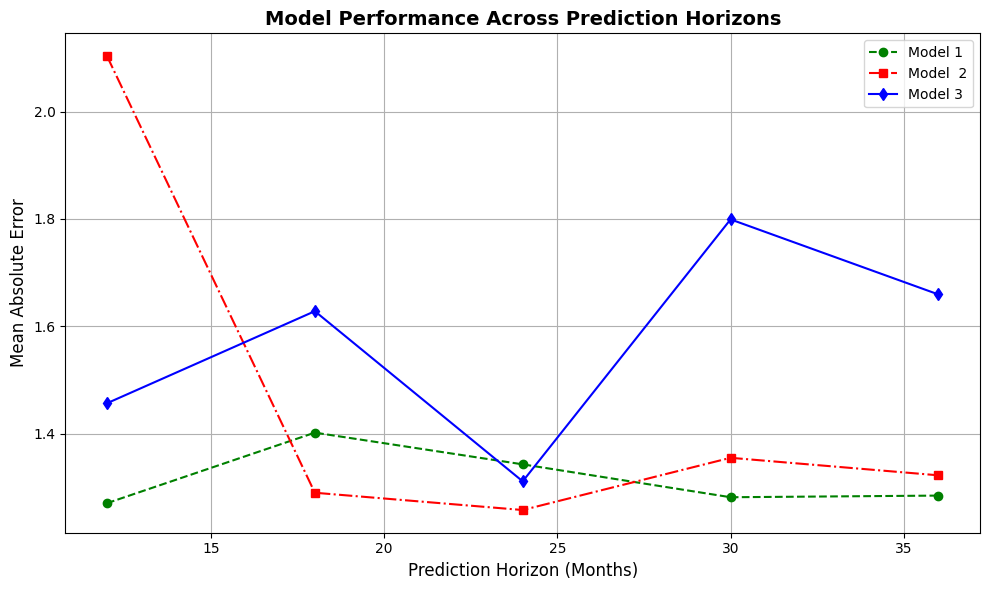

In [11]:
def comparision_plot(horizons, model1_MAEs, model2_MAEs, model3_MAEs, figsize=(10, 6)):
    """
    Plot the MAE comparison across prediction horizons for three models for part ii.
    
    Parameters:
        horizons(list): List of target lengths used for prediction.
        model1_MAEs(list): MAE values for Model 1.
        model2_MAEs(list): MAE values for Model 2.
        model3_MAEs(list): MAE values for Model 3.
        figsize(tuple): Size of the figure.

    """

    #Plot the MAEs comparision
    plt.figure(figsize=figsize)
    plt.plot(horizons, model1_MAEs, 'o--', label='Model 1', color = 'green')
    plt.plot(horizons, model2_MAEs, 's-.', label='Model  2', color = 'red')
    plt.plot(horizons, model3_MAEs, 'd-', label='Model 3', color = 'blue')
    plt.xlabel('Prediction Horizon (Months)', fontsize=12)
    plt.ylabel('Mean Absolute Error', fontsize=12)
    plt.title('Model Performance Across Prediction Horizons', fontsize=14, fontweight='bold')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


#MAEs already collected in part c, d and e should be inserted here: and should be in the index 0 cause has to increase the range
model1_MAEs.insert(0, mae_partc)
model2_MAEs.insert(0, mae_partd)
model3_MAEs.insert(0, mae_parte)

#Horizon values
horizons = [12, 18, 24, 30, 36]

#Plot
comparision_plot(horizons, model1_MAEs, model2_MAEs, model3_MAEs)

### Discussions:

***MAE Comparison Table:***

| Prediction Horizon (Months) | Model 1 MAE | Model 2 MAE | Model 3 MAE |
|-----------------------------|-------------|-------------|-------------|
| 12                          | 1.3332      | 1.1942      | 1.3842      |
| 18                          | 1.4861      | 1.3267      | 1.6801      |
| 24                          | 1.2673      | 1.3319      | 1.4232      |
| 30                          | 1.3382      | 2.1154      | 1.5509      |
| 36                          | 1.3314      | 1.3154      | 1.4759      |





***Comment on plot and MAE table***<br>

From the MAE table and the plotted trends, we can observe the following:

- Model 1 shows relatively consistent performance across all horizons. Although there is a slight increase at 18 months, it recovers quickly and maintains a stable MAE even at longer prediction lengths. This suggests that it generalizes well and handles long term temperature forecasting effectively. One reason for its robustness is that it was trained to predict the full target sequence, and it is evaluated on the same horizon length ensuring consistency between training and testing.


- Model 2 performs well for shorter horizons but deteriorates the fastest as the prediction horizon increases. The sharp MAE increase at 30 months indicates that the model is sensitive to error accumulation, if the first prediction is inaccurate, the error carries over into future steps, resulting in a compounding effect. However, for short term forecasting (e.g: one month ahead), Model 2 will be effective, since it was trained for one step predictions and performs best when used in that way.


- Model 3 performs moderately well across all horizons. Although it doesn't outperform Model 1, it generally stays below Model 2 error, especially at longer horizons like 30 and 35 months, as shown in the plot. This behavior is due to its encoder decoder architecture. Because the decoder starts with the ground truth as its first input, the model begins inference with a more accurate context. This helps reduce early error drift and delays the onset of error accumulation. Consequently, Model 3 is less susceptible to compounding errors and demonstrates more stable recovery over extended forecast windows compared to Model 2.

So, the answer for which model deteriorates fastest would be model 2 as it tends to accumulate the error and it is evident in the plot as well during the horizon 30.



***Generalization to Another Weather Station***<br>

The generalization capability of each model depends on both the similarity of weather patterns between stations and the type of prediction required.

If the target station exhibits similar seasonal patterns to the one used for training, the models are likely to perform comparably. Model 1, which was trained to predict a full sequence (e.g: 12 months), could still perform well even if used to predict fewer months (e.g: 5), since its architecture is robust and directly models the entire target range. It is generally the safest choice for generalization across a variety of forecasting horizons.

Model 2, being a recursive one step model, performs well for very short term forecasting. If the goal is to predict only the next 1 to 2 months, it can be effective when transferred to another station. However, its performance drops sharply for longer horizons due to error accumulation, which would be especially risky if the new station’s data distribution is even slightly different.

Model 3, which uses an encoder decoder architecture, is potentially better suited for longer prediction horizons at a new station. Its design allows it to model temporal dependencies across the entire sequence, and it can recover better from error drift. While it’s not as consistent as Model 1, it is more robust than Model 2 in generalizing longer range temporal patterns, making it a good candidate for mid to long-range forecasting in a new location.

**In summary:**<br>

Use Model 1 when robustness and flexibility are key. It is designed to directly map a past input sequence to a full future output in one step, making it efficient and consistently accurate across horizons. However, since it does not model the temporal relationships between future months, it may be less suitable for scenarios where such dependencies matter like forecasting turning points or seasonal transitions.<br>

Use  Model 2 if the goal is short term (e.g: next 1 to 2 months) prediction only.<br>

Use Model 3 when longer prediction horizons are involved and the outputs are expected to have temporal dependencies across time, for example, when July’s temperature may affect the trend in November. In such cases, sequence to sequence modeling via an encoder decoder architecture is beneficial because it generates each future step step by step, allowing previous predictions and the encoded context to influence future outputs. This makes it better suited for capturing long term and complex relationships.

# Part 2 - VAE
The task is to train VAE on maximum temprature sequences of 84 months, and generate synthetic sequences by randomly sampling 6 latent coding vectors.

In [12]:
#Check the min and max value in the train_seq for proper scaling 
min_temp = tf.reduce_min(train_seq[:,:,1])
max_temp = tf.reduce_max(train_seq[:,:,1])
print("Minimum max-temp:", min_temp.numpy())
print("Maximum max-temp:", max_temp.numpy())

Minimum max-temp: 16.2
Maximum max-temp: 36.3


VAE is a generative model that learns to represent input data as a probability distribution in a lower dimensional latent space, rather than encoding it into a fixed vector.
Instead of producing a single latent code, the encoder outputs the mean and variance of a latent distribution, from which samples are drawn and passed to the decoder for reconstruction.<br>

During training, the model learns by minimizing two losses:<br>
i) The reconstruction loss - to ensure the output closely matches the input.<br>
ii) The KL divergence - to make the learned latent distribution close to a standard normal distribution.

### Implementation
I implemented VAE with a custom Sampling layer, an encoder, and a decoder using fully connected layers. The model takes 84 month temperature sequences as input, maps them to a latent space of dimension 10, and reconstructs the input from sampled latent vectors. The following are the key components of my architecture and how they function:

***Sampling layer***<br>
In a VAE, instead of producing a fixed latent code, the encoder learns a distribution (mean and log variance) that represents how the input could vary in the latent space. We then need to sample from this learned distribution so the model can generate diverse yet realistic outputs. However, because direct sampling is a random process, we can’t backpropagate through it.
To solve this, I implemented a custom Sampling layer that uses the reparameterization trick, it takes the mean and log variance from the encoder and generates latent vectors using random noise. This layer also calculates the KL divergence loss during training and adds it to the total loss, helping the model learn both accurate reconstructions and a well regularized latent space.

***Encoder***<br>
The encoder takes the input temperature sequence of length 84 and first normalizes it to the range of [0 and 1] based on the training data's min and max values that T mentioned above. It then passes the normalized input through two fully connected layers with ReLU activations to extract features. Finally, it outputs two separate vectors for each latent dimension, the mean and log variance, which define the parameters of the latent distribution. These two vectors are then passed to the Sampling layer to generate a latent vector that will be used by the decoder.

***Decoder***
The decoder takes the sampled latent vector from the Sampling layer as input and tries to reconstruct the original 84 month temperature sequence. It passes this latent vector through two fully connected layers with ReLU activation to expand and transform the compressed information back into the original shape. The final output layer has 84 units (matching the input sequence length), and a Lambda layer is used to rescale the output back to the original temperature range using the same min and max values from the training data.

After building above components, to build the complete VAE model, I connected the encoder and decoder into a single end to end architecture. The input sequence is first passed through the encoder, which outputs the mean, log variance, and a sampled latent vector. This latent vector is then passed to the decoder, which reconstructs the original temperature sequence. The model is trained end to end using both reconstruction loss and the KL divergence loss (added inside the Sampling layer), allowing it to learn both how to compress and generate realistic sequences.


**Training Setup**<br>
I compiled the VAE using the Nadam optimizer and used MAE as the reconstruction loss, since the task involves predicting continuous temperature values. The model was trained on normalized 84 month sequences (train_seq[:, :, 1]) with early stopping and a learning rate scheduler was also used similarly, to monitor the training progress, I plotted the training and validation MAE curves.


***Why Scaling ?***<br>
I scale the data to [0, 1] before feeding it into the VAE because  Scaling makes the latent learning and decoding process much more stable and meaningful. VAE is learning to model the distribution. If the data is left unscaled the input distribution would lie in an arbitrary range which makes it harder for the model to learn a stable latent representation. The latent space is sampled from a standard normal distribution, and the decoder tries to map those values back to the original space. Without scaling, the mismatch in magnitude between latent values (around 0) and original data values (16–36) can cause poor reconstructions. To avoid this, I scale the data and bring all temperature values to a fixed [0, 1] range, so VAE can focus on learning the pattern instead of trying to learn the original scale. The decoder outputs remain in a consistent range, and I can easilyrescale back to the original temperature range after generation,



Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_10 (Functional)      │ [(None, 10), (None,    │         8,180 │
│                                 │ 10), (None, 10)]       │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_11 (Functional)      │ (None, 84)             │         7,924 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,104 (62.91 KB)

 Trainable params: 16,104 (62.91 KB)

 Non-trainable params: 0 (0.00 B)

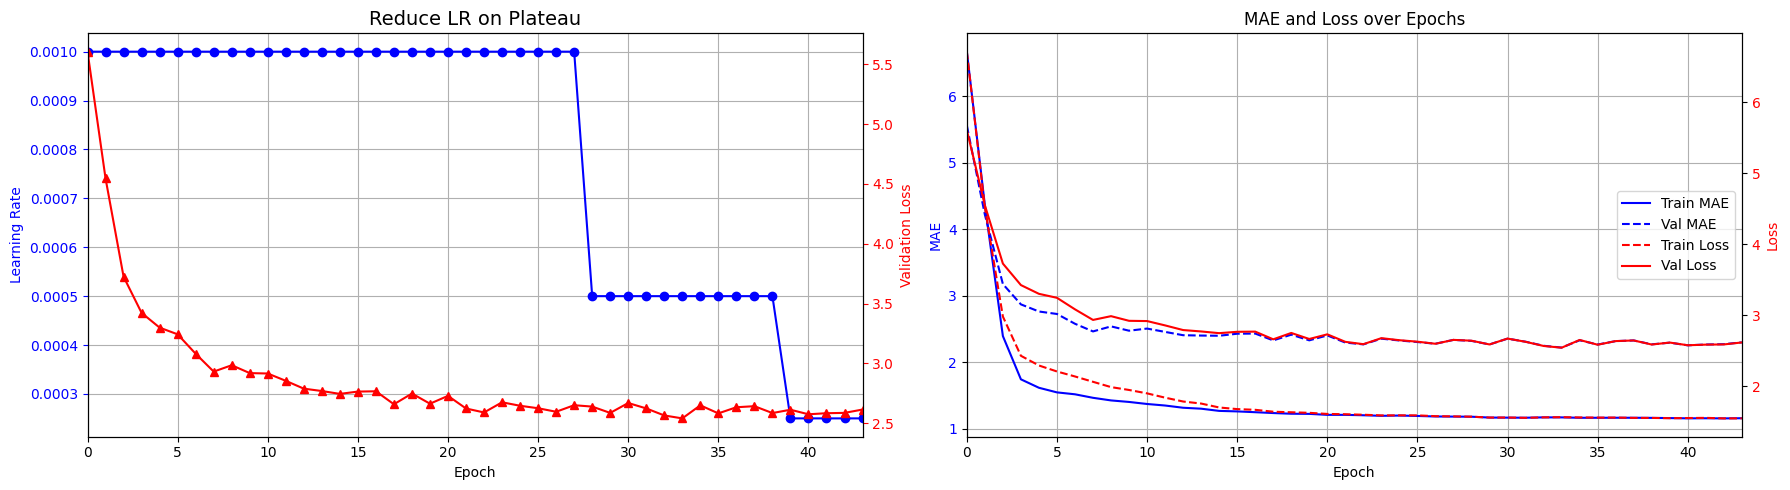

In [13]:
#Variational Autoencoders:
latent_dim = 10
class Sampling(tf.keras.Layer):
    def call(self, inputs):
        mean, logvar = inputs

        #sum the losses 
        loss = -0.5 * tf.reduce_sum(1 + logvar - tf.exp(logvar) - tf.square(mean), axis = 1) #mean across latent dimension
        self.add_loss(tf.reduce_mean(loss ) / latent_dim) #latent dimension would be number of output encoder will be passing - this is for normalisation
        return tf.random.normal(tf.shape(logvar)) * tf.exp(logvar/2) + mean

#Encoder Block
encoder_inputs = tf.keras.layers.Input(shape = (84,))
normalized = tf.keras.layers.Lambda(lambda x: (x - min_temp) / (max_temp - min_temp))(encoder_inputs)
X = tf.keras.layers.Dense(64, activation = 'relu')(normalized)
X = tf.keras.layers.Dense(32, activation = 'relu')(X)
encoding_mean = tf.keras.layers.Dense(latent_dim)(X)
encoding_logVar = tf.keras.layers.Dense(latent_dim)(X)
#Now sampling
X = Sampling()(inputs = [encoding_mean, encoding_logVar])
variational_encoder = tf.keras.Model(inputs = encoder_inputs, outputs = [encoding_mean, encoding_logVar, X])

#Decoder Block
decoder_inputs = tf.keras.layers.Input(shape=(latent_dim,))
Y = tf.keras.layers.Dense(32, activation = 'relu')(decoder_inputs)
Y = tf.keras.layers.Dense(64, activation = 'relu')(Y)
Y = tf.keras.layers.Dense(84)(Y)
outputs = tf.keras.layers.Lambda(lambda x: x * (max_temp - min_temp) + min_temp)(Y)
variational_decoder = tf.keras.Model(inputs = decoder_inputs, outputs = outputs)

#Combine encoder and decoder
variationalAE_inputs = tf.keras.layers.Input(shape = (84,))
encodings_mean, encodings_logVar, encodings = variational_encoder(variationalAE_inputs)
reconstructions = variational_decoder(encodings)
variationalAE = tf.keras.Model(inputs=variationalAE_inputs, outputs=reconstructions)
variationalAE.summary()

#Compile and train the model
variationalAE.compile(optimizer = tf.keras.optimizers.Nadam(), loss = 'mae', metrics = ['mae'])
historyVAE = train_model(model=variationalAE, X_train=train_seq[:, :, 1], y_train=train_seq[:, :, 1], X_val=val_seq[:, :, 1], y_val=val_seq[:, :, 1], batch_size=32, epochs=100,
                        stop=10, reduceOn=5, reduceBy=0.5, min_lr=1e-6)

#Training Curves
plot(historyVAE)

***Parameters Summary***<br>
The VAE model consists of a total of 16,104 trainable parameters, with no non trainable parameters. These parameters are distributed across the encoder, decoder, and latent space projection layers.


***Training Curves and Learning Behaviour***<br>
From the left plot, we can see that the learning rate stayed constant at 0.0010 until around epoch 23, after which it was reduced twice once at epoch 25 and again at epoch 35 due to the ReduceLROnPlateau scheduler triggering.

On the right plot, the Train MAE drops to around 1.2, while the Validation MAE stabilizes close to 2.4, meaning the average reconstruction error on validation data is less than 2 degree celcius higher then on the training data. This small gap suggests the model generalizes well. The loss curves also show smooth convergence, with no sharp spikes or divergence, indicating stable and effective training.



### Experimentation on synthesized temprature sequence:
After training, and from the loss curves I can see that the reconstruction error is low, which means the encoder has learned to provide a good latent distribution, and the decoder has learned how to reconstruct the temperature patterns well. Since the decoder was trained to generate sequences from sampled latent vectors, it should now be able to take any random input of the correct latent dimension (10) and produce a realistic synthetic temperature sequence that follows the learned patterns.<br>

However, A low reconstruction error alone doesnot confirm a well organised latent space to verify the structure and generative quality by sampling and decoding latent vectors.

As per the description, I sampled 6 random vectors from a standard normal distribution and passed them to the decoder as mention in the chunk below:

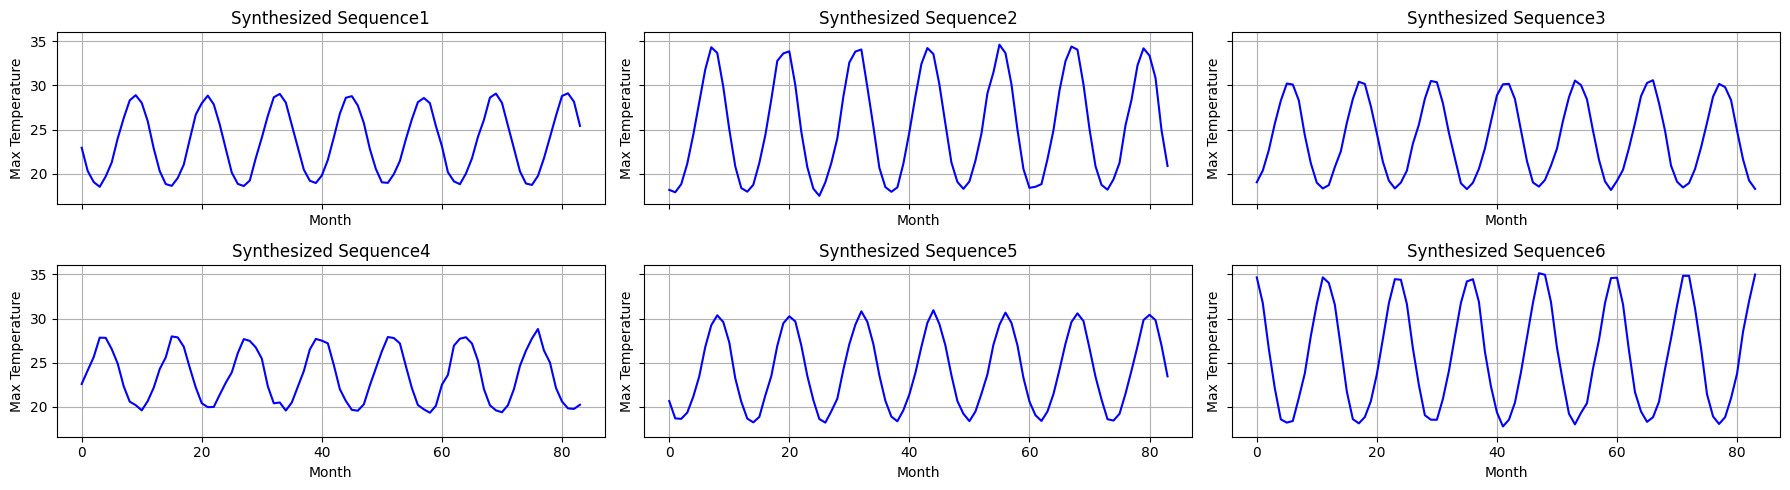

In [14]:
#Generate 6 random latent samples
n_samples = 6
random_encodings = tf.random.normal(shape=(n_samples, latent_dim))

#Decode the samples
decoded_sequences = variational_decoder.predict(random_encodings, verbose=0)

#Plot temprature
display_temperatures(title="Synthesized Sequence",decoded_sequences = decoded_sequences, num_samples=6, n_samples= n_samples, mode = 'synthesized', n_rows=2, n_cols=3, figsize=(18,5))

***Expectations:***<br>
My expectation was that the decoder would generate sequences that are smooth, seasonal, and realistic, with values falling in the typical range of temperature and no sudden spikes or erratic behaviour.

***Reality***<br>
After sampling six random latent vectors from a standard normal distribution and decoding them, the generated sequences appeared highly smooth and cyclic, each displaying clear seasonal oscillations similar to sine waves. The temperature ranges were realistic and consistent with training data, confirming that the decoder captured dominant temporal trends.<br>

However, all generated sequences were almost identical overly smooth and nearly indistinguishable from one another. This lack of diversity suggested that the model was relying on a limited portion of the latent space, implying that the encoder may have collapsed much of the latent representation toward the origin. To answer the reason I conducted a diagonostics which are mentioned in the later chunks:

### Diagonostics
I have conducted thorough diagnostic analysis and answered why decoded sequences are like sinusodial in the last markdowncell. 

#### Why VAE decoded sequences like sinusoidal?
To understand that, I first went back how decoder is receiving input mathematically:<br>
Decoder sees samples drawn from the latent distributions learned by the encoder for each training input. Here, the latent distribution is expected to be a Gaussian defined by the encoder's output mean and variance. 
However, this latent distribution is not learned freely it is shaped by the training objective, which balances two competing goals:<br>
i) The reconstruction loss pushes the decoder to accurately reproduce the input sequence from the sampled latent vector.<br>
ii) The KL divergence loss tries to make the latent distribution stay close to a standard normal distribution, acting as a regulariser 

If the KL divergence becomes too dominant, the encoder may start producing very similar distributions, regardless of the input. This would cause most latent vectors to cluster in a narrow region, meaning the decoder learns to map only from a small portion of latent space which could explain why my generated sequences all looked identical sinusoids.

To check whether this was happening, I decided to analyze what the encoder was actually outputting during training by inspecting the distribution of mean values and the standard deviation of each latent dimension. For that, I used the trained encoder to predict the mean vectors for each training sequence and then I plotted, a KDE plot of all latent mean values to analyze their distribution as in the next chunk.

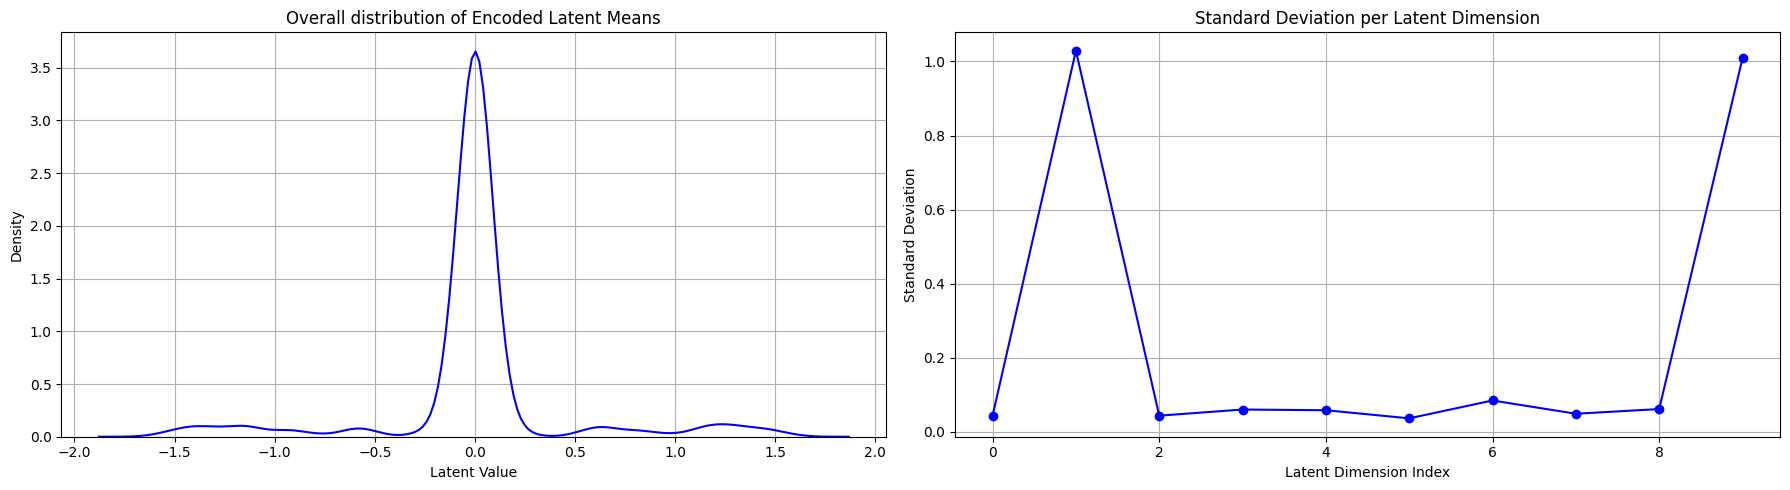

In [15]:
#Predict means from encoder
means, _, _ = variational_encoder.predict(train_seq[:, :, 1], verbose=0)
#Flatten for KDE
flat_means = means.flatten()
#Standard deviation per latent dimension
latent_std = np.std(means, axis=0)

#Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
#KDE Plot for latent means
sns.kdeplot(flat_means, color='blue', ax=axes[0])
axes[0].set_title("Overall distribution of Encoded Latent Means")
axes[0].set_xlabel("Latent Value")
axes[0].grid(True)

#Std dev plot per dimension
axes[1].plot(latent_std, marker='o', color='blue')
axes[1].set_title("Standard Deviation per Latent Dimension")
axes[1].set_xlabel("Latent Dimension Index")
axes[1].set_ylabel("Standard Deviation")
axes[1].grid(True)
plt.tight_layout()
plt.show()


***Comment on distribution:***<br>
As shown in the plot above, the distribution of encoded means is narrow and peaked around 0. This indicates that the encoder is not spreading the input sequences widely in latent space, but instead is mapping most of them to a very tight cluster near the origin. This supports the earlier hypothesis:<br>
So, the decoder only saw samples from a very small region of latent space during training.<br>
This kind of distribution could be due to model not using the full capacity of the latent dimensions. <br>

To understand that further, I needed to check how many latent dimensions the decoder was actually using to reconstruct the input. For that, I plotted the standard deviation per latent dimension across all the encoded mean vectors.

***Comment on Latent Dimension Usage(Right plot):***<br>
The plot above shows the standard deviation of the encoded mean values for each of the 10 latent dimensions across the training set. As can be seen, only two latent dimensions (dim 3 and dim 5) have significant variability, while the rest are close to zero. This confirms that the encoder is only using a small subset of the latent space to represent the input sequences.  The remaining dimensions contribute almost nothing and are effectively ignored by the decoder during reconstruction.

As a result, when we sampled from the full latent space during random sequence generation, most dimensions didnt influence the output at all leading to highly repetitive and similar sequences.

### Final Check if actually the decoder depending on Two latent dimensions only??
To verify the decoder’s dependency on these active dimensions, two controlled decoding experiments were conducted:
- Zero Vector test: Feeding the decoder the mean of the latent prior distribution that the encoder is trained to approximate.
- Selective injection test: Injecting small nonzero values only in dimensions 3 and 5 while keeping all others zeroed

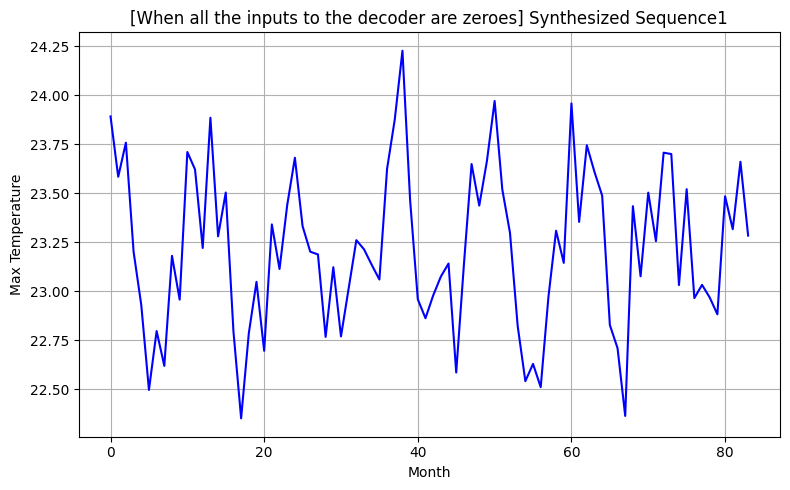

In [16]:
#Checking how well model could learn when passed all inputs to be 0 to the decoder
random_encodings = tf.zeros(shape=[1, latent_dim])
#Decode the samples
decoded_sequences = variational_decoder.predict(random_encodings, verbose=0)

#Plot temprature
display_temperatures(title= "[When all the inputs to the decoder are zeroes] Synthesized Sequence", decoded_sequences = decoded_sequences, num_samples=1, n_rows = 1, n_cols = 1, mode = 'synthesized', figsize=(8,5))    

***Comment on the plot: [Notice the temprature range - couldnt retain]***<br>

Although the sequence exhibits some temporal variation, it fails to retain the full temperature range seen in the training data. The output is narrowly concentrated between 22.5 degree C and 24.5 degree C, lacking the diversity and seasonal amplitude present in original sequences. This result indicates that the decoder, when unconditioned by informative latent features, generates a generic output. This outcome reinforces the earlier hypothesis that the model underutilizes the latent space, relying heavily on a small subset of active dimensions.

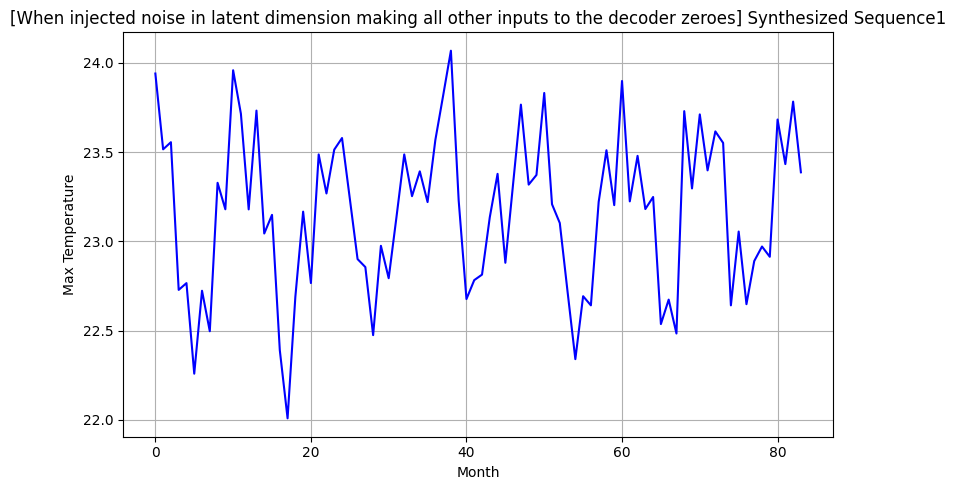

In [17]:
random_encodings = np.zeros((1, latent_dim))
random_encodings[0, 3] = 1.0 
random_encodings[0, 5] = -0.5

#Decode the samples
decoded_sequences = variational_decoder.predict(random_encodings, verbose=0)

#Plot temprature
display_temperatures(title= "[When injected noise in latent dimension making all other inputs to the decoder zeroes] Synthesized Sequence", decoded_sequences = decoded_sequences, num_samples=1, n_rows = 1, n_cols = 1, mode = 'synthesized', figsize=(8,5))    



***Comment on the plot: [Notice the temprature range]***<br>
When noise was injected only in latent dimensions 3 and 5, while keeping all other dimensions zeroed out, the decoder generated a smooth, periodic sinusoidal sequence with good range. This confirms that the decoder is highly sensitive to variations in this specific latent dimension, which carries meaningful generative information. It also highlights that the decoder relies on a very small subset of active latent dimensions, while the rest contribute minimally reinforcing the diagnosis of latent space underutilization. 

***Conclusion:***<br>
After performing a thorough set of diagnostics including variance analysis of latent dimensions, zero vector decoding, and selective activation tests it became clear that the decoder in my VAE is overly reliant on just a few specific latent dimensions (notably dimension 3 and 5). The rest of the latent space contributes very little to the reconstruction, leading to underutilization of the latent space. This explains why randomly sampled generations appeared overly smooth and repetitive.